In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor,GradientBoostingRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

import warnings
warnings.filterwarnings('ignore')
import datetime


Loading Dataset

In [109]:
df = pd.read_csv('global_cars_enhanced.csv')
df.head()

,Car_ID,Brand,Manufacture_Year,Body_Type,Fuel_Type,Transmission,Engine_CC,Horsepower,Mileage_km_per_l,Price_USD,Manufacturing_Country,Car_Age,Price_Category,HP_per_CC,Age_Category,Efficiency_Score
0,CAR_0001,Mercedes,2006,SUV,Petrol,Manual,4089,547,17,73407,USA,20,Premium,0.1338,Old,0.35
1,CAR_0002,Nissan,2023,Coupe,Petrol,Automatic,4618,167,25,79370,USA,3,Premium,0.0362,New,0.75
2,CAR_0003,Nissan,2007,Hatchback,Diesel,Manual,1802,110,16,76549,China,19,Premium,0.0610,Old,0.30
3,CAR_0004,Nissan,2013,Coupe,Petrol,Manual,1835,373,16,48722,USA,13,Mid-Range,0.2033,Old,0.30
4,CAR_0005,Hyundai,2009,Hatchback,Hybrid,Automatic,2332,145,28,83265,UK,17,Premium,0.0622,Old,0.90


EDA

In [110]:
df.shape

(300, 16)

In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Car_ID                 300 non-null    object 
 1   Brand                  300 non-null    object 
 2   Manufacture_Year       300 non-null    int64  
 3   Body_Type              300 non-null    object 
 4   Fuel_Type              300 non-null    object 
 5   Transmission           300 non-null    object 
 6   Engine_CC              300 non-null    int64  
 7   Horsepower             300 non-null    int64  
 8   Mileage_km_per_l       300 non-null    int64  
 9   Price_USD              300 non-null    int64  
 10  Manufacturing_Country  300 non-null    object 
 11  Car_Age                300 non-null    int64  
 12  Price_Category         300 non-null    object 
 13  HP_per_CC              300 non-null    float64
 14  Age_Category           300 non-null    object 
 15  Effici

In [112]:
df.describe()

,Manufacture_Year,Engine_CC,Horsepower,Mileage_km_per_l,Price_USD,Car_Age,HP_per_CC,Efficiency_Score
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,2015.123333,3052.880000,328.346667,19.716667,60848.823333,10.876667,0.129559,0.485833
std,5.966023,1117.937497,153.202644,6.028061,34445.525598,5.966023,0.093239,0.301403
min,2005.000000,1001.000000,70.000000,10.000000,5221.000000,1.000000,0.017800,0.000000
25%,2010.000000,2074.000000,188.250000,15.000000,29418.500000,6.000000,0.063250,0.250000
50%,2015.000000,3117.500000,329.500000,19.500000,59179.500000,11.000000,0.106850,0.475000
75%,2020.000000,3964.000000,454.750000,24.000000,89692.250000,16.000000,0.168325,0.700000
max,2025.000000,4994.000000,599.000000,30.000000,119587.000000,21.000000,0.525500,1.000000


Data cleaning

In [113]:
df.isna().sum()

Car_ID                   0
Brand                    0
Manufacture_Year         0
Body_Type                0
Fuel_Type                0
Transmission             0
Engine_CC                0
Horsepower               0
Mileage_km_per_l         0
Price_USD                0
Manufacturing_Country    0
Car_Age                  0
Price_Category           0
HP_per_CC                0
Age_Category             0
Efficiency_Score         0
dtype: int64

In [114]:
df['Brand'].unique()

array(['Mercedes', 'Nissan', 'Hyundai', 'Tesla', 'Audi', 'Honda', 'Ford',
       'Toyota', 'BMW', 'Kia'], dtype=object)

In [115]:
df['Fuel_Type'].unique()

array(['Petrol', 'Diesel', 'Hybrid', 'Electric'], dtype=object)

In [116]:
df['Body_Type'].unique()

array(['SUV', 'Coupe', 'Hatchback', 'Sedan', 'Pickup'], dtype=object)

In [117]:
df['Manufacture_Year'].unique()

array([2006, 2023, 2007, 2013, 2009, 2012, 2011, 2016, 2017, 2020, 2025,
       2019, 2014, 2010, 2005, 2022, 2021, 2024, 2008, 2018, 2015])

In [118]:
df['Transmission'].unique()

array(['Manual', 'Automatic'], dtype=object)

In [119]:
df['Manufacturing_Country'].unique()

array(['USA', 'China', 'UK', 'Japan', 'Germany', 'South Korea'],
      dtype=object)

In [120]:
df['Price_Category'].unique()

array(['Premium', 'Mid-Range', 'Budget', 'Luxury'], dtype=object)

In [121]:
df['Age_Category'].unique()

array(['Old', 'New', 'Moderate', 'Recent'], dtype=object)

In [122]:
df['Price']=df['Price_USD'].astype(int)
df.head()

,Car_ID,Brand,Manufacture_Year,Body_Type,Fuel_Type,Transmission,Engine_CC,Horsepower,Mileage_km_per_l,Price_USD,Manufacturing_Country,Car_Age,Price_Category,HP_per_CC,Age_Category,Efficiency_Score,Price
0,CAR_0001,Mercedes,2006,SUV,Petrol,Manual,4089,547,17,73407,USA,20,Premium,0.1338,Old,0.35,73407
1,CAR_0002,Nissan,2023,Coupe,Petrol,Automatic,4618,167,25,79370,USA,3,Premium,0.0362,New,0.75,79370
2,CAR_0003,Nissan,2007,Hatchback,Diesel,Manual,1802,110,16,76549,China,19,Premium,0.0610,Old,0.30,76549
3,CAR_0004,Nissan,2013,Coupe,Petrol,Manual,1835,373,16,48722,USA,13,Mid-Range,0.2033,Old,0.30,48722
4,CAR_0005,Hyundai,2009,Hatchback,Hybrid,Automatic,2332,145,28,83265,UK,17,Premium,0.0622,Old,0.90,83265


Label encoding

In [123]:
df_scaled=df.copy()
qualitative_cols=['Brand','Fuel_Type','Transmission','Body_Type','Manufacturing_Country','Price_Category','Age_Category']
encoder= LabelEncoder()

for col in qualitative_cols:
    df_scaled[col]= encoder.fit_transform(df_scaled[col])

df_scaled.head()



,Car_ID,Brand,Manufacture_Year,Body_Type,Fuel_Type,Transmission,Engine_CC,Horsepower,Mileage_km_per_l,Price_USD,Manufacturing_Country,Car_Age,Price_Category,HP_per_CC,Age_Category,Efficiency_Score,Price
0,CAR_0001,6,2006,3,3,1,4089,547,17,73407,5,20,3,0.1338,2,0.35,73407
1,CAR_0002,7,2023,0,3,0,4618,167,25,79370,5,3,3,0.0362,1,0.75,79370
2,CAR_0003,7,2007,1,0,1,1802,110,16,76549,0,19,3,0.0610,2,0.30,76549
3,CAR_0004,7,2013,0,3,1,1835,373,16,48722,5,13,2,0.2033,2,0.30,48722
4,CAR_0005,4,2009,1,2,0,2332,145,28,83265,4,17,3,0.0622,2,0.90,83265


Standard scaling

In [124]:
scaler= StandardScaler()
numeric_cols=['Brand','Fuel_Type','Transmission','Body_Type','Manufacture_Year','Horsepower','Car_Age','Price_Category','HP_per_CC','Age_Category']
df_scaled[numeric_cols]=scaler.fit_transform(df_scaled[numeric_cols])
df_scaled.head()

,Car_ID,Brand,Manufacture_Year,Body_Type,Fuel_Type,Transmission,Engine_CC,Horsepower,Mileage_km_per_l,Price_USD,Manufacturing_Country,Car_Age,Price_Category,HP_per_CC,Age_Category,Efficiency_Score,Price
0,CAR_0001,0.408864,-1.531770,0.604007,1.316957,0.967204,4089,1.429601,17,73407,5,1.531770,1.349519,0.045558,0.350699,0.35,73407
1,CAR_0002,0.754383,1.322460,-1.470827,1.316957,-1.033908,4618,-1.054918,25,79370,5,-1.322460,1.349519,-1.002964,-0.597136,0.75,79370
2,CAR_0003,0.754383,-1.363874,-0.779216,-1.352550,0.967204,1802,-1.427596,16,76549,0,1.363874,1.349519,-0.736536,0.350699,0.30,76549
3,CAR_0004,0.754383,-0.356499,-1.470827,1.316957,0.967204,1835,0.291953,16,48722,5,0.356499,0.459726,0.792200,0.350699,0.30,48722
4,CAR_0005,-0.282174,-1.028083,-0.779216,0.427121,-1.033908,2332,-1.198759,28,83265,4,1.028083,1.349519,-0.723645,0.350699,0.90,83265


In [125]:
df_scaled.drop('Car_ID',axis=1,inplace=True)
df_scaled.head()

,Brand,Manufacture_Year,Body_Type,Fuel_Type,Transmission,Engine_CC,Horsepower,Mileage_km_per_l,Price_USD,Manufacturing_Country,Car_Age,Price_Category,HP_per_CC,Age_Category,Efficiency_Score,Price
0,0.408864,-1.531770,0.604007,1.316957,0.967204,4089,1.429601,17,73407,5,1.531770,1.349519,0.045558,0.350699,0.35,73407
1,0.754383,1.322460,-1.470827,1.316957,-1.033908,4618,-1.054918,25,79370,5,-1.322460,1.349519,-1.002964,-0.597136,0.75,79370
2,0.754383,-1.363874,-0.779216,-1.352550,0.967204,1802,-1.427596,16,76549,0,1.363874,1.349519,-0.736536,0.350699,0.30,76549
3,0.754383,-0.356499,-1.470827,1.316957,0.967204,1835,0.291953,16,48722,5,0.356499,0.459726,0.792200,0.350699,0.30,48722
4,-0.282174,-1.028083,-0.779216,0.427121,-1.033908,2332,-1.198759,28,83265,4,1.028083,1.349519,-0.723645,0.350699,0.90,83265


Data visualization

<Axes: >

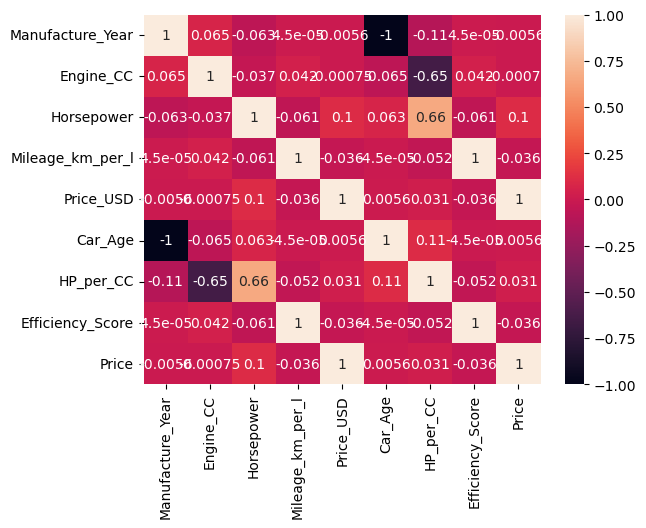

In [126]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [127]:
df.corr(numeric_only=True)['Price'].sort_values(ascending=False)

Price_USD           1.000000
Price               1.000000
Horsepower          0.104940
HP_per_CC           0.030636
Car_Age             0.005602
Engine_CC          -0.000749
Manufacture_Year   -0.005602
Mileage_km_per_l   -0.035517
Efficiency_Score   -0.035517
Name: Price, dtype: float64

<Axes: xlabel='Mileage_km_per_l', ylabel='Price'>

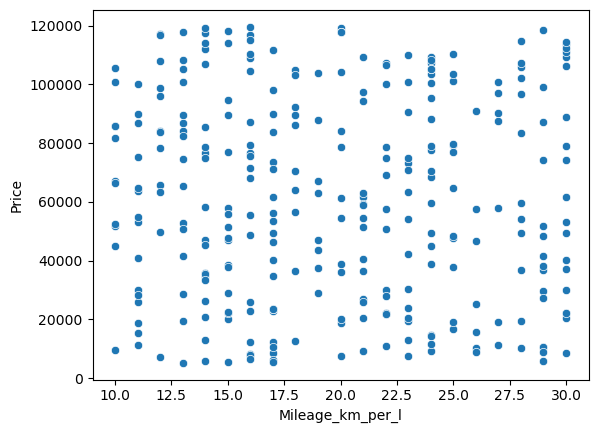

In [128]:
sns.scatterplot(data=df,x='Mileage_km_per_l',y='Price')

<Axes: xlabel='Price', ylabel='Count'>

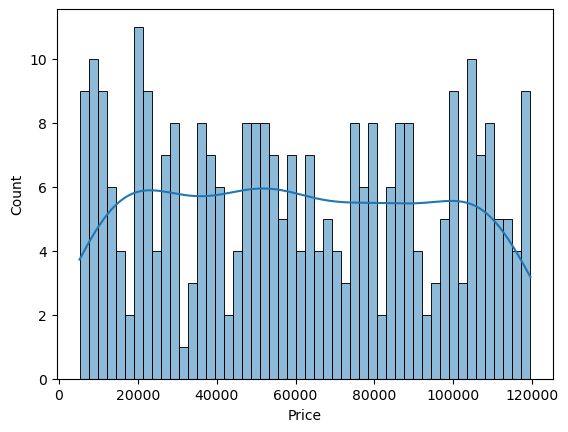

In [129]:
sns.histplot(df['Price'],bins=50,kde=True)

<Axes: xlabel='Transmission', ylabel='Price'>

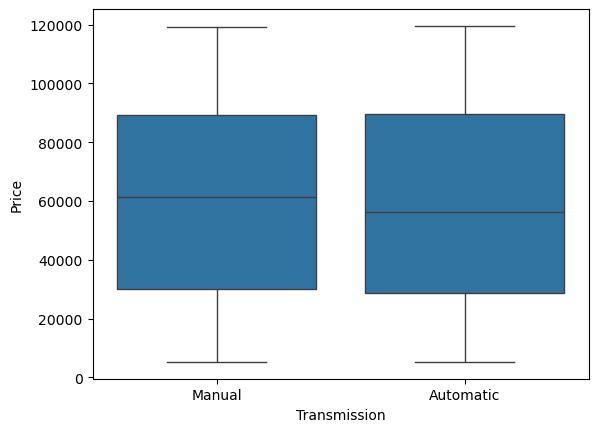

In [130]:
sns.boxplot(data=df,x='Transmission',y='Price')

<Axes: xlabel='Manufacturing_Country', ylabel='count'>

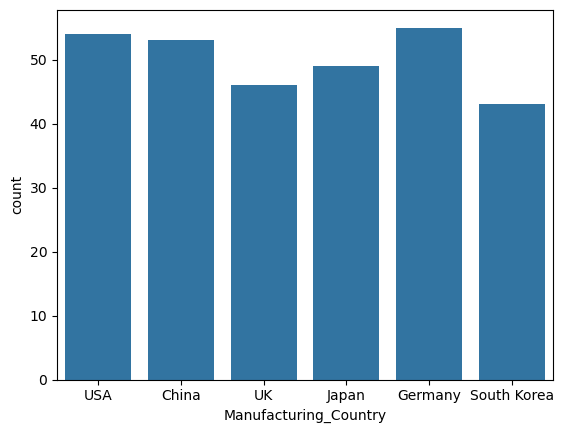

In [131]:
sns.countplot(x=df['Manufacturing_Country'])

<Axes: xlabel='Body_Type', ylabel='count'>

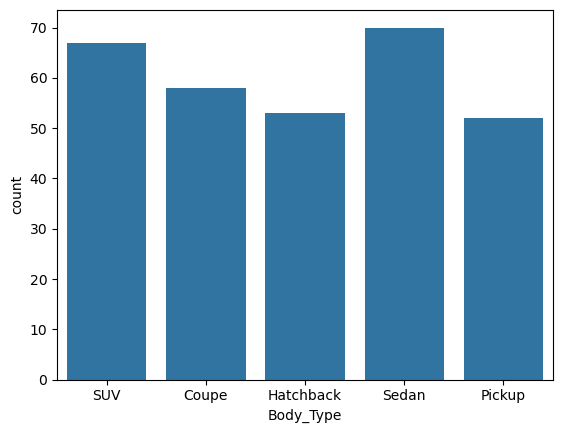

In [132]:
sns.countplot(x=df['Body_Type'])

<Axes: xlabel='Fuel_Type', ylabel='count'>

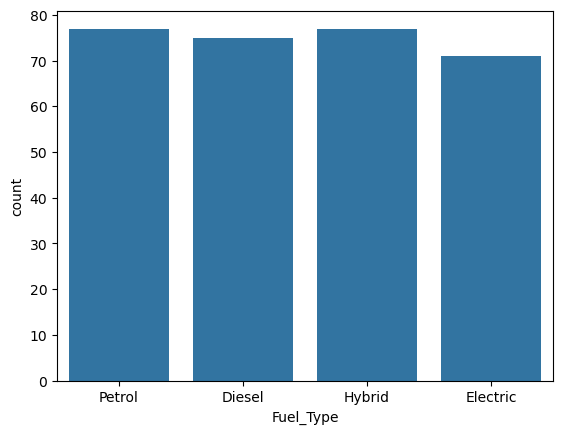

In [133]:
sns.countplot(x=df['Fuel_Type'])

<Axes: xlabel='Price_Category', ylabel='count'>

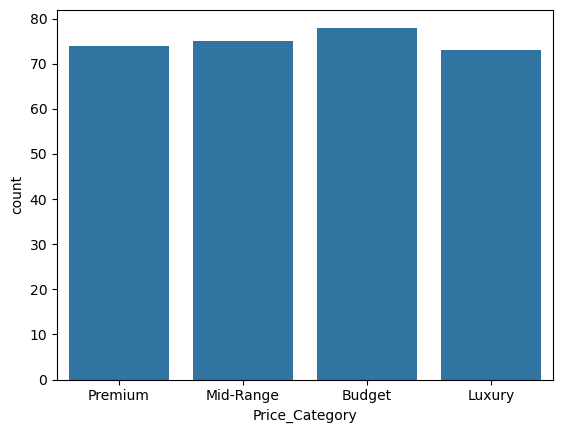

In [134]:
sns.countplot(x=df['Price_Category'])

Spliting data

In [135]:
df.columns

Index(['Car_ID', 'Brand', 'Manufacture_Year', 'Body_Type', 'Fuel_Type',
       'Transmission', 'Engine_CC', 'Horsepower', 'Mileage_km_per_l',
       'Price_USD', 'Manufacturing_Country', 'Car_Age', 'Price_Category',
       'HP_per_CC', 'Age_Category', 'Efficiency_Score', 'Price'],
      dtype='object')

In [136]:
X=df_scaled.drop(['Price','Price_USD','Engine_CC','Manufacturing_Country','Mileage_km_per_l','Efficiency_Score'],axis=1)
y=df['Price']

Train Test split

In [137]:
XTrain,XTest,yTrain,yTest= train_test_split(X,y,test_size=0.2,random_state=42)

Model tunning

In [138]:
models={
    'linear':LinearRegression(fit_intercept=True,copy_X=True,tol=1e-06,n_jobs=1,positive=False),
    'randomForest': RandomForestRegressor(n_estimators=100,min_samples_leaf=1,min_samples_split=5,max_depth=5,random_state=42),
    'adaBoost': AdaBoostRegressor(n_estimators=500,loss='linear',learning_rate=0.5,random_state=42),
    'gradientboost':GradientBoostingRegressor(subsample=1.0,n_estimators=100,min_samples_split=10,min_samples_leaf=1,max_depth=3,learning_rate=0.05,random_state=42)
}

In [139]:
results = []

for name, model in models.items():
    model.fit(XTrain, yTrain)
    y_pred = model.predict(XTest)

    results.append({
        "Model": name,
        "R2": r2_score(yTest, y_pred),
        "MAE": mean_absolute_error(yTest, y_pred),
        "RMSE": np.sqrt(mean_squared_error(yTest, y_pred))
    })

results_df = pd.DataFrame(results)
results_df.sort_values("R2", ascending=False)

,Model,R2,MAE,RMSE
2,adaBoost,0.941009,7235.414705,8481.872575
1,randomForest,0.929752,7881.574646,9255.855277
3,gradientboost,0.926700,7819.578024,9454.818558
0,linear,0.203378,25530.645826,31169.243927


Inputs

In [140]:
X.columns

Index(['Brand', 'Manufacture_Year', 'Body_Type', 'Fuel_Type', 'Transmission',
       'Horsepower', 'Car_Age', 'Price_Category', 'HP_per_CC', 'Age_Category'],
      dtype='object')

In [141]:
Brand = input("Enter Brand: ")
Manufacture_Year = int(input("Enter Manufacture Year: "))
Body_Type = input("Enter Body Type (Sedan/SUV/Hatchback/Coupe/Pickup): ")
Fuel_Type = input("Enter Fuel Type (Petrol/Diesel/Electric/Hybrid): ")
Transmission = input("Enter Transmission (Manual/Automatic): ")
Engine_CC = float(input("Enter Engine CC: "))
Horsepower = float(input("Enter Horsepower: "))
current_year = datetime.datetime.now().year
Car_Age = current_year - Manufacture_Year
HP_per_CC = Horsepower / Engine_CC if Engine_CC != 0 else 0
Price_Category = input("Enter Price Category (Premium/Mid-Range/Budget/Luxury): ")
Age_Category = input("Enter Age Category (Old/New/Moderate/Recent): ")


inputs = pd.DataFrame({
    'Brand': [Brand],
    'Manufacture_Year': [Manufacture_Year],
    'Body_Type': [Body_Type],
    'Fuel_Type': [Fuel_Type],
    'Transmission': [Transmission],
    'Horsepower': [Horsepower],
    'Car_Age': [Car_Age],
    'Price_Category': [Price_Category],
    'HP_per_CC': [HP_per_CC],
    'Age_Category': [Age_Category]
})

inputs_scaled=inputs.copy()
qualitative_cols=['Brand','Body_Type','Fuel_Type','Transmission','Price_Category','Age_Category']
for col in qualitative_cols:
    encoder=LabelEncoder()
    inputs_scaled[col]= encoder.fit_transform(inputs_scaled[col])
    
numeric_cols=['Brand', 'Manufacture_Year', 'Body_Type', 'Fuel_Type', 'Transmission',
       'Horsepower', 'Car_Age', 'Price_Category', 'HP_per_CC', 'Age_Category']
scaler=StandardScaler()
inputs_scaled[numeric_cols]=scaler.fit_transform(inputs_scaled[numeric_cols])

y_pred=models['adaBoost'].predict(inputs_scaled)

print(f"Car price may be: {y_pred}")
print(f"Input details:")
print(inputs)

Car price may be: [108426.75675676]
Input details:
  Brand  Manufacture_Year Body_Type Fuel_Type Transmission  Horsepower  \
0  ford              2020       SUV    Petrol       Manual       400.0   

   Car_Age Price_Category  HP_per_CC Age_Category  
0        6         Luxury   0.111111          New  


In [142]:
import pickle

artifacts = {
    "model": models["adaBoost"],
    "scaler": scaler,
    "encoders": {}
}

for col in qualitative_cols:
    le = LabelEncoder()
    df_scaled[col] = le.fit_transform(df[col])
    artifacts["encoders"][col] = le

with open("car_price_model.pkl", "wb") as f:
    pickle.dump(artifacts, f)

In [143]:
print(scaler.feature_names_in_)

['Brand' 'Manufacture_Year' 'Body_Type' 'Fuel_Type' 'Transmission'
 'Horsepower' 'Car_Age' 'Price_Category' 'HP_per_CC' 'Age_Category']
